# EXPLORATORY DATA ANALYSIS (EDA)
## Engine Health Monitoring – CMAPSS Dataset

### Objective
Understand sensor behavior, engine degradation patterns, and relationships between operational cycles and sensor readings before feature engineering.


### **Import Libraries**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)


## **Load Cleaned Data**

In [4]:
DATA_PATH = "../data/processed/train_engine_data_clean.csv"

df = pd.read_csv(DATA_PATH)

df.head()


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## **Dataset Overview**

In [6]:
print("Shape of Dataset:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())

Shape of Dataset: (20631, 26)

Column Names:
 ['engine_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']


## **Basic Statistical Summary**

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
engine_id,20631.0,51.506568,2.922763e+01,1.0000,26.0000,52.0000,77.0000,100.0000
cycle,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.0000,156.0000,362.0000
op_setting_1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.0000,0.0015,0.0087
op_setting_2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.0000,0.0003,0.0006
op_setting_3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
sensor_1,20631.0,518.670000,6.537152e-11,518.6700,518.6700,518.6700,518.6700,518.6700
sensor_2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
sensor_3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
sensor_4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
sensor_5,20631.0,14.620000,3.394700e-12,14.6200,14.6200,14.6200,14.6200,14.6200


## **Check Engine Count**

In [8]:
print("Total Unique Engines:", df["engine_id"].nunique())

Total Unique Engines: 100


## **Cycle Distribution**

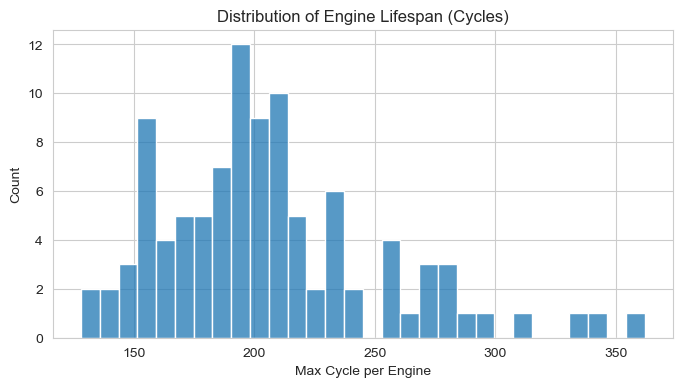

In [9]:
engine_cycles = df.groupby("engine_id")["cycle"].max()

plt.figure(figsize=(8,4))
sns.histplot(engine_cycles, bins=30)
plt.title("Distribution of Engine Lifespan (Cycles)")
plt.xlabel("Max Cycle per Engine")
plt.ylabel("Count")
plt.show()

## **Sensor Distribution (Example Sensors)**

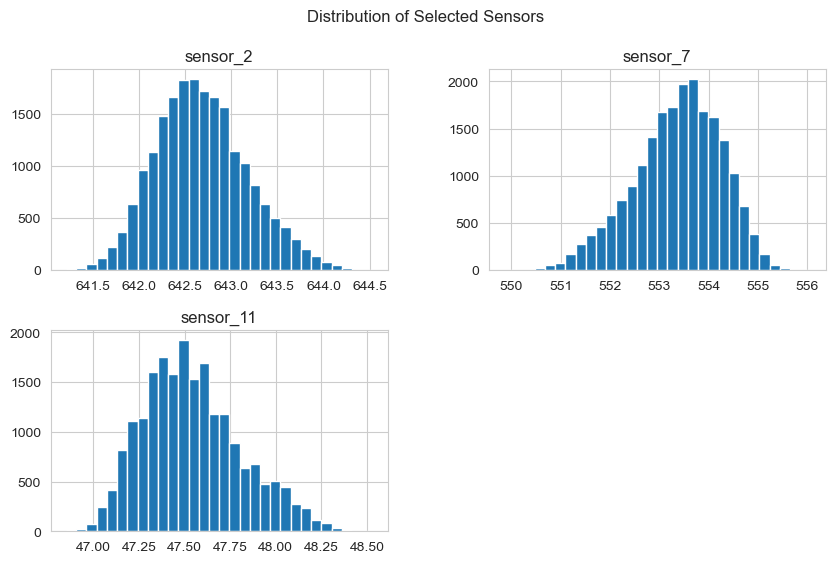

In [10]:
selected_sensors = ["sensor_2", "sensor_7", "sensor_11"]

df[selected_sensors].hist(figsize=(10,6), bins=30)
plt.suptitle("Distribution of Selected Sensors")
plt.show()

## **Correlation Analysis**

In [12]:
cycle_corr = df.corr()["cycle"].sort_values(ascending=False)
cycle_corr.head(10)

cycle        1.000000
sensor_11    0.634385
sensor_4     0.624577
sensor_15    0.588676
sensor_17    0.566995
sensor_2     0.549898
sensor_3     0.543947
sensor_13    0.477523
sensor_8     0.475977
sensor_9     0.443999
Name: cycle, dtype: float64

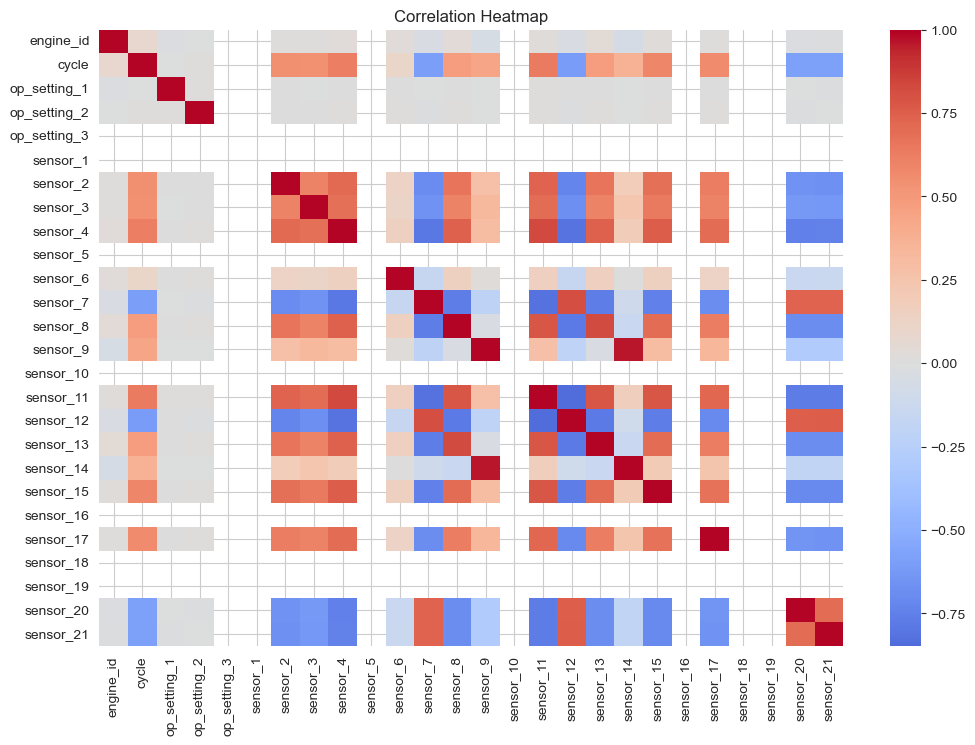

In [13]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

## **Sensor Trend Over Time (Single Engine)**

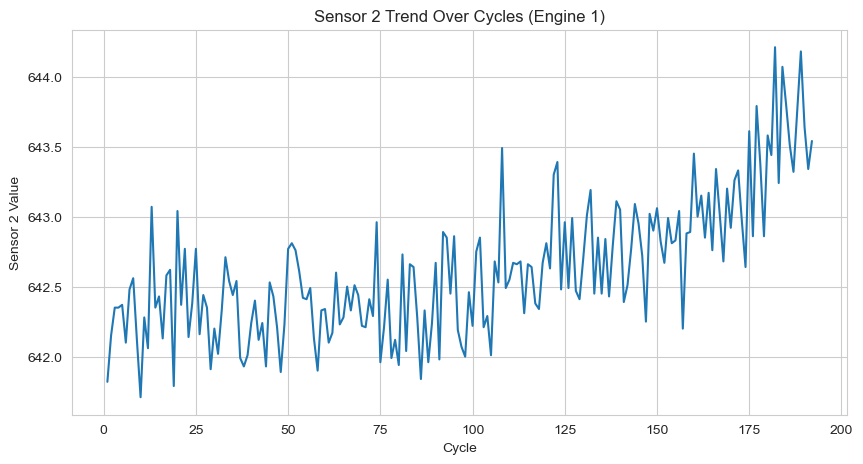

In [14]:
engine_sample = df[df["engine_id"] == 1]

plt.figure(figsize=(10,5))
plt.plot(engine_sample["cycle"], engine_sample["sensor_2"])
plt.title("Sensor 2 Trend Over Cycles (Engine 1)")
plt.xlabel("Cycle")
plt.ylabel("Sensor 2 Value")
plt.show()

## **Sensor Variability Ranking**

In [15]:
sensor_cols = [col for col in df.columns if "sensor" in col]

variance = df[sensor_cols].var().sort_values(ascending=False)

variance.head(10)

sensor_9     487.653568
sensor_14    363.900490
sensor_4      81.010886
sensor_3      37.590994
sensor_17      2.398667
sensor_7       0.783388
sensor_12      0.543985
sensor_2       0.250053
sensor_11      0.071336
sensor_20      0.032669
dtype: float64

## **Outlier Detection (Boxplot)**

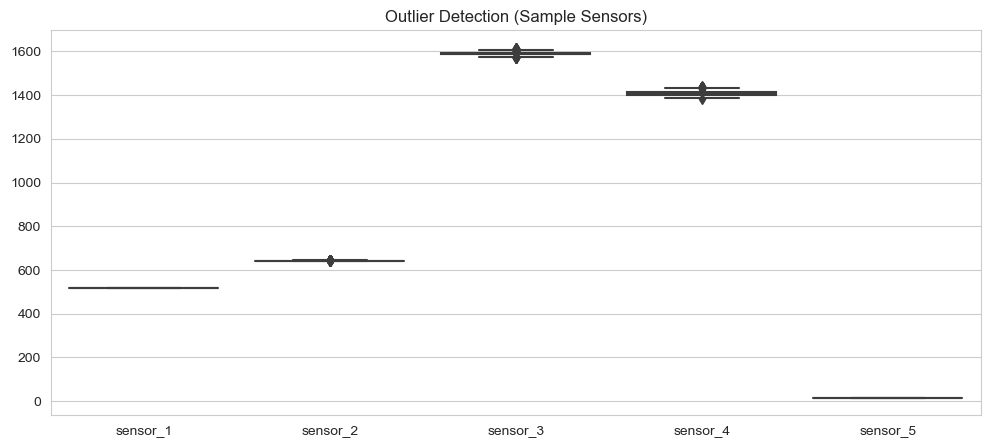

In [16]:
plt.figure(figsize=(12,5))
sns.boxplot(data=df[sensor_cols[:5]])
plt.title("Outlier Detection (Sample Sensors)")
plt.show()

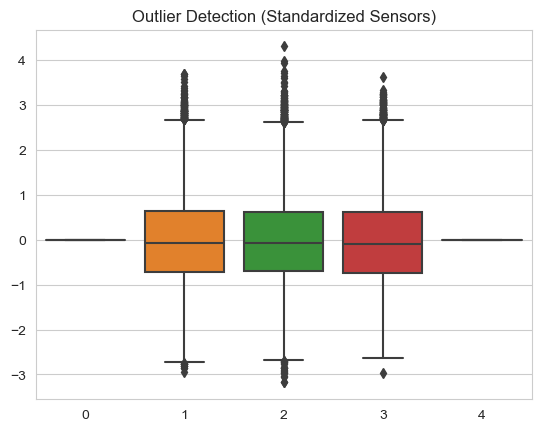

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled = scaler.fit_transform(df[sensor_cols[:5]])

sns.boxplot(data=scaled)
plt.title("Outlier Detection (Standardized Sensors)")
plt.show()


### **Add Sensor Stability Detection**

In [18]:
low_variance_sensors = variance[variance < 0.001]
low_variance_sensors

sensor_6     1.929279e-06
sensor_1     4.273435e-21
sensor_5     1.152399e-23
sensor_10    2.172333e-25
sensor_16    2.422479e-28
sensor_18    0.000000e+00
sensor_19    0.000000e+00
dtype: float64

These sensors show near-zero variance and will be removed in feature engineering as they do not provide predictive value.

## **Add Engine-Level Summary**

In [20]:
engine_summary = df.groupby("engine_id")["cycle"].max().describe()
engine_summary

count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64

## **Add Correlation Filtering Logic**

In [21]:
high_corr = df.corr().abs()
upper_triangle = high_corr.where(
    np.triu(np.ones(high_corr.shape), k=1).astype(bool)
)

high_corr_features = [
    column for column in upper_triangle.columns
    if any(upper_triangle[column] > 0.95)
]

high_corr_features

['sensor_14']

In [22]:
important_sensors = cycle_corr[abs(cycle_corr) > 0.5]
important_sensors

cycle        1.000000
sensor_11    0.634385
sensor_4     0.624577
sensor_15    0.588676
sensor_17    0.566995
sensor_2     0.549898
sensor_3     0.543947
sensor_20   -0.583597
sensor_21   -0.585923
sensor_7    -0.595914
sensor_12   -0.611354
Name: cycle, dtype: float64

Sensors with correlation magnitude greater than 0.5 with cycle are strong degradation indicators and will be prioritized for RUL modeling.

## **Missing Value Confirmation**

In [19]:
df.isna().sum()

engine_id       0
cycle           0
op_setting_1    0
op_setting_2    0
op_setting_3    0
sensor_1        0
sensor_2        0
sensor_3        0
sensor_4        0
sensor_5        0
sensor_6        0
sensor_7        0
sensor_8        0
sensor_9        0
sensor_10       0
sensor_11       0
sensor_12       0
sensor_13       0
sensor_14       0
sensor_15       0
sensor_16       0
sensor_17       0
sensor_18       0
sensor_19       0
sensor_20       0
sensor_21       0
dtype: int64

### **Sensor Selection Strategy**

- Sensors strongly correlated with cycle will be retained.
- Low variance sensors will be removed.
- Highly redundant sensors will be evaluated during feature engineering.
- Dataset is suitable for RUL modeling.

# **EDA Conclusion**

### **Key Findings:**

- Dataset contains 100 engines with varying lifespan.

- Several sensors show strong degradation patterns.

- Some sensors are constant and will be removed.

- Cycle strongly correlates with selected sensors.

- Dataset is suitable for RUL modeling.